# Anomaly Investigation: Soft Signals (Cross-Column Checks, Continued)

The four **hard invariants** originally explored here (timestamp ordering, `has_refund` consistency, the section-5 crosstab re-verification, and over-refund bounds) all came back either with zero exceptions or matching an already-known cluster exactly - so they were migrated into `01_eda.ipynb` (section 6) as confirmed integrity checks rather than kept here as an open investigation.

What remains here are the **soft signals**: statistically unusual patterns that are not logical impossibilities on their own, and only become evidence once they show concentration in time or category.

Standalone notebook — reloads and prepares the data independently of `01_eda.ipynb`.

In [1]:
import pandas as pd

df = pd.read_csv('/home/veronika/Anomaly_Hunter_Solidgate/hackathon_int20h_dataset_test.csv')

In [2]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])

## Theory: what is an invariant?

An invariant is a rule that must always hold given the business logic of the domain — a statement of the form *"if column A has value X, then column B must satisfy condition Y, always, with zero exceptions."* An invariant is already implicit in a finding from `01_eda.ipynb` (section 5): `order_payment_type` is populated exactly when `order_type == recurring`. That relationship was discovered with a crosstab — this notebook generalizes the same idea to a checklist of rules, applied deliberately rather than found by accident.

**Two categories of check — keep them separate, they carry different weight as evidence:**

- **Hard invariant** — a logical impossibility if violated. Example: a failed payment cannot have a positive refund, because money that was never charged cannot be refunded. A violation here is strong evidence of a data-quality problem or an injected anomaly, because *no legitimate business scenario produces it*. High precision by construction — this is why the psp_beta "fail + refunded_amount > 0" combination was such solid evidence in the refund notebook.
- **Soft signal** — statistically unusual, but not logically impossible on its own. Example: `ip_country != bin_country` — perfectly normal for a traveler using their home card abroad. A soft signal only becomes evidence once it shows **concentration** (in time, in one `psp_id`, in one `currency`) — exactly like psp_gamma's latency spike was a soft signal (delay alone proves nothing) until it was shown to concentrate in a specific PSP and a specific week.

**A trap to watch for.** `pd.crosstab(..., normalize='index')` in section 5 of `01_eda.ipynb` confirmed several relationships with a share of `1.0` — but a *proportion* rounds to `1.0` easily even with a handful of exceptions in a column of ~400,000-600,000 rows (399,997 out of 400,000 also prints as `1.0000` at four decimal places). A percentage is not proof of zero exceptions. Before trusting a "confirmed" crosstab result, cross-check it with an **exact row count** of the violating condition — the same correction that was needed in section 10, where an aggregate currency-sum view gave a misleading signal until it was replaced by a row-level check.

## General method (apply this to every rule below)

1. Write the rule as a boolean mask over the dataframe — a condition that should match **zero** rows (or, for a "must always" rule, a condition that should be true for 100% of rows).
2. Count exact violations with `.sum()` on the boolean mask — not a percentage.
3. If violations exist: profile the violating subset with the same toolbox used in every earlier investigation (`.nunique()`, `.describe()`, `value_counts()` per column), and check whether it concentrates in a time window / `psp_id` / `bank_id` / `currency` — the way every confirmed anomaly so far did.
4. If violations are scattered uniformly across time and category with no concentration, it is more likely ordinary data noise than an anomaly cluster. Use judgement — the same judgement call that excluded `psp_alpha`'s fail rate in `03_anomaly_latency_psp_gamma.ipynb`.


## Soft signals (need corroboration, not conclusive alone)

These are not logical impossibilities - each has legitimate real-world explanations. Per the theory above, treat any of them as a lead only if it **concentrates** somewhere, using the same category x time scan approach as `03_anomaly_latency_psp_gamma.ipynb` section 9.

### B1. `ip_country` vs `bin_country` mismatch rate

**Rule of thumb:** a mismatch is normal at some baseline rate (travelers, VPNs, expats). Only a spike above that baseline, concentrated in time or category, would be evidence of something else.

In [3]:
df['is_mismatch'] = df['ip_country'] != df['bin_country']
print(f"Country mismatch: {df['is_mismatch'].sum()} rows ({df['is_mismatch'].mean()*100:.2f}%)")

Country mismatch: 144262 rows (14.43%)


**Baseline:** 144,262 rows, 14.43% of the dataset.

In [4]:
by_bin = df.groupby('bin_country')['is_mismatch'].agg(['size', 'mean'])
by_bin.columns = ['total_transactions', 'mismatch_rate_pct']
by_bin['mismatch_rate_pct'] = (by_bin['mismatch_rate_pct'] * 100).round(2)
by_bin = by_bin.sort_values('mismatch_rate_pct', ascending=False)

by_ip = df.groupby('ip_country')['is_mismatch'].agg(['size', 'mean'])
by_ip.columns = ['total_transactions', 'mismatch_rate_pct']
by_ip['mismatch_rate_pct'] = (by_ip['mismatch_rate_pct'] * 100).round(2)
by_ip = by_ip.sort_values('mismatch_rate_pct', ascending=False)

print(by_bin)
print()
print(by_ip)

             total_transactions  mismatch_rate_pct
bin_country                                       
MEX                       62228              31.35
POL                       70468              27.67
GBR                       70789              27.45
FRA                       70623              27.41
DEU                       70487              27.40
UKR                       70981              27.22
CAN                      146130              12.09
USA                      438294               2.32

            total_transactions  mismatch_rate_pct
ip_country                                       
GBR                      60159              14.64
POL                      59636              14.53
USA                     500471              14.45
FRA                      59892              14.40
CAN                     150032              14.38
DEU                      59767              14.38
MEX                      49810              14.24
UKR                      60233         

**Finding:** rate by `bin_country` ranges from 2.32% (USA) to 31.35% (MEX) - a 13x spread. Rate by `ip_country` is flat, 14.2-14.6% everywhere. This asymmetry is explained by population skew: `ip_country` is 50% USA, `bin_country` only 44% USA - so foreign-issued cards are disproportionately used from a US IP simply because that's where most of the traffic is, inflating their raw mismatch rate mechanically.

In [5]:
ip_share = df['ip_country'].value_counts(normalize=True)
by_bin['expected_mismatch_pct'] = (by_bin.index.map(lambda c: 1 - ip_share.get(c, 0)) * 100).round(2)
by_bin['loyalty_effect'] = (by_bin['expected_mismatch_pct'] - by_bin['mismatch_rate_pct']).round(2)
print(by_bin.sort_values('loyalty_effect', ascending=False))

             total_transactions  mismatch_rate_pct  expected_mismatch_pct  \
bin_country                                                                 
CAN                      146130              12.09                  85.00   
UKR                       70981              27.22                  93.98   
DEU                       70487              27.40                  94.02   
FRA                       70623              27.41                  94.01   
GBR                       70789              27.45                  93.98   
POL                       70468              27.67                  94.04   
MEX                       62228              31.35                  95.02   
USA                      438294               2.32                  49.95   

             loyalty_effect  
bin_country                  
CAN                   72.91  
UKR                   66.76  
DEU                   66.62  
FRA                   66.60  
GBR                   66.53  
POL                

**Finding (population-adjusted):** `expected_mismatch_pct` is the rate that pure chance would produce given each country's share of `ip_country` (`1 - ip_share`); `loyalty_effect` is the gap between that and the observed rate - how much more "home-loyal" a country's cardholders are than randomness would predict. Ranking flips: CAN is the most loyal (72.9 pts), USA the least (47.6 pts) once its size is accounted for, and UKR/DEU/FRA/GBR/POL form a tight cluster (66.4-66.8 pts) with MEX just below (63.7). A clean North-America-vs-rest split, consistent across five independent countries - this reads as real customer geography, not an injected pattern.

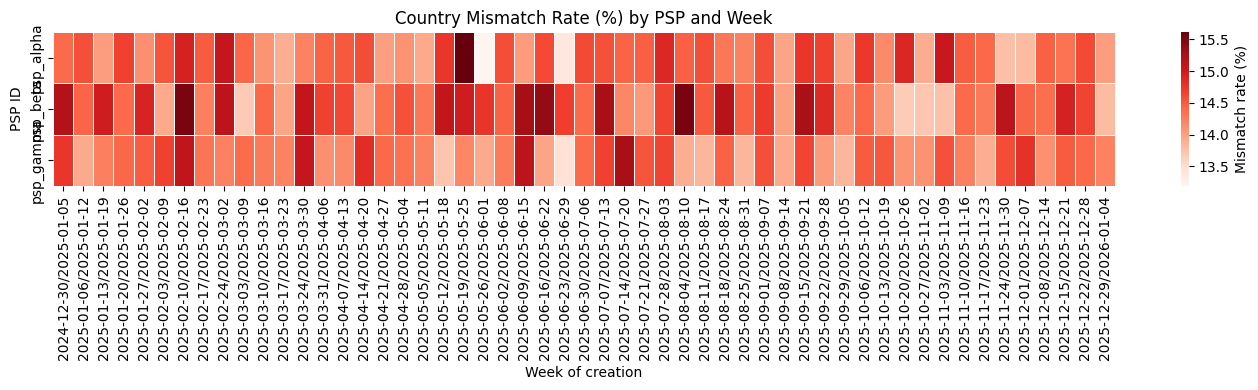

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df['week'] = df['created_at'].dt.to_period('W').astype(str)
rate_by_week = df.pivot_table(values='is_mismatch', index='psp_id', columns='week', aggfunc='mean') * 100

plt.figure(figsize=(14, 4))
sns.heatmap(rate_by_week, cmap='Reds', linewidths=0.5, cbar_kws={'label': 'Mismatch rate (%)'})
plt.title('Country Mismatch Rate (%) by PSP and Week')
plt.xlabel('Week of creation')
plt.ylabel('PSP ID')
plt.tight_layout()
plt.show()

In [7]:
mid = df['created_at'].median()
half_comparison = df.assign(half=(df['created_at'] >= mid).map({True: 'H2', False: 'H1'})) \
    .pivot_table(values='is_mismatch', index='psp_id', columns='half', aggfunc='mean') * 100
half_comparison['diff_pp'] = (half_comparison['H2'] - half_comparison['H1']).round(2)
print(half_comparison.round(2))

half          H1     H2  diff_pp
psp_id                          
psp_alpha  14.36  14.40     0.04
psp_beta   14.64  14.48    -0.17
psp_gamma  14.38  14.29    -0.09


**Finding:** H2-H1 difference is 0.04, -0.09 and -0.17 percentage points across the three PSPs - an order of magnitude smaller than the week-to-week noise (std ~0.4-0.5 pp, full range 13.2-15.6%). No real trend; the "darkening" seen in an earlier raw-count heatmap was a volume-growth artifact, not a rate change.

**Conclusion (B1):** `ip_country`/`bin_country` mismatch is a real, stable demographic characteristic of the customer base (strong North-America home-market loyalty, weaker but consistent loyalty elsewhere), with no time or category concentration. Same treatment as `psp_alpha`'s fail rate: kept as background context, not a labeling signal.

### B2. Zero-amount transactions

In [8]:
zero_amount = df['amount'] == 0
print("Zero-amount transactions:", zero_amount.sum())

Zero-amount transactions: 0


**Conclusion (B2):** zero occurrences. Closed.

### B3. `is_secured` vs outcome

Two questions: does the 3D-Secure flag correlate with a different fail rate, and does the failure-reason mix (`error_code`) differ between secured and unsecured transactions?

In [9]:
df['is_fail'] = df['status'] != 'success'

fail_by_security = df.groupby('is_secured')['is_fail'].agg(['size', 'mean'])
fail_by_security.columns = ['total_transactions', 'fail_rate_pct']
fail_by_security['fail_rate_pct'] = (fail_by_security['fail_rate_pct'] * 100).round(2)
print(fail_by_security)

            total_transactions  fail_rate_pct
is_secured                                   
False                   957663          47.45
True                     42337          48.38


**Finding:** 47.45% (unsecured) vs 48.38% (secured) - under 1 percentage point apart. No meaningful effect on fail rate.

In [10]:
failed = df[df['is_fail'] & df['error_code'].notna()]

error_mix = pd.crosstab(failed['error_code'], failed['is_secured'], normalize='columns') * 100
error_counts = pd.crosstab(failed['error_code'], failed['is_secured'])

error_profile = pd.DataFrame({
    'count_unsecured': error_counts[False],
    'count_secured': error_counts[True],
    'pct_within_unsecured': error_mix[False].round(2),
    'pct_within_secured': error_mix[True].round(2),
}).sort_values('count_unsecured', ascending=False)

print(error_profile)

            count_unsecured  count_secured  pct_within_unsecured  \
error_code                                                         
3.02                 143806           6315                 31.65   
3.08                  87080           3213                 19.16   
3.10                  73537           3260                 16.18   
2.01                  42803            893                  9.42   
3.04                  41079           1817                  9.04   
2.12                  40831           3869                  8.99   
4.09                  16897            750                  3.72   
4.03                   1466             54                  0.32   
0.01                   1401             67                  0.31   
5.01                   1396             60                  0.31   
3.05                   1392             50                  0.31   
3.01                   1389             79                  0.31   
2.03                   1326             56      

**Finding:** no `error_code` is exclusive to either group - not a hard invariant violation. Two codes stand out from the rest: `2.12` is 18.89% of secured failures vs 8.99% of unsecured (over 2x), and `2.01` is 4.36% of secured vs 9.42% of unsecured (about half). Every other code is within 1-4 points between groups. Without Solidgate's error-code dictionary this can't be labeled with certainty, but the pattern (one code enriched, one depleted, rest proportional) is consistent with a real 3DS-specific decline reason rather than a data artifact.

**Conclusion (B3):** no logical contradiction found; the `error_code` skew is plausibly explained by real payment semantics. Descriptive finding, not a labeling signal.

## Escalation checklist

Reuse this checklist for *any* violation found above that isn't immediately zero — it mirrors the profiling already done for psp_beta in section 10 of `04_anomaly_refund_psp_beta.ipynb`:

1. Exact row count of the violation, and its share of the relevant total (not the whole dataset if the rule only applies to a subset).
2. `nunique()` and `value_counts()` per column on the violating subset — look for a single dominant `psp_id`/`bank_id`/`currency`.
3. Is the violation's magnitude constant (like the flat `+10` refund gap or the exact `5s` latency), or variable (like the psp_gamma 1-2h range)? Constant magnitude is a stronger signal of synthetic insertion; variable magnitude looks more like a real operational incident.
4. Time profile: single day (synthetic-looking) vs multi-day gradual pattern (incident-looking) vs uniformly scattered across the year (probably not a cluster at all).
5. Does the violating window/group account for 100% of a related metric for the whole year (like the over-refund cases did), or only part of it?


## Conclusions

| Check | Result | Verdict |
|---|---|---|
| A1-A4 (hard invariants, see `01_eda.ipynb` §6) | 0 exceptions on 3 rules; 4th rule's 2,691 hits are the already-known psp_beta cluster | Confirmed clean / no new cluster |
| B1: `ip_country` vs `bin_country` mismatch | 14.43% baseline; strong NA-vs-rest split explained by customer geography; no time/category concentration | Background characteristic, not a signal |
| B2: zero-amount transactions | 0 occurrences | Closed |
| B3: `is_secured` vs outcome/`error_code` | Fail rate unaffected (<1pp); 2 error codes skew as expected for a real 3DS decline reason | Explainable, not a signal |

No new anomaly cluster surfaced from systematic invariant/signal checking - a useful negative result: it bounds the three clusters found in `01`-`04` as the dataset's main synthetic/incident anomalies rather than the tip of a larger iceberg. See `05_conclusions_next_steps.ipynb` for the cross-notebook summary and the plan for further checks.